# TCREmp VDJdb Analysis (mirpy)

This notebook reproduces the core `tcremp_vdjdb` workflow using `mirpy` APIs and
AIRR benchmark assets from Hugging Face.

Pipeline:
1. Load VDJdb slim from `isalgo/airr_benchmark`.
2. Build TRB clonotypes and labels (`antigen.epitope`).
3. Embed with `TCREmp`.
4. Evaluate representation with PCA/UMAP, DBSCAN, and classifiers.
5. Compare `fixed_gap` vs `biopython` backends (runtime + predictive quality).

In [1]:
import importlib.metadata as _meta
import sys as _sys
print(f"Python {_sys.version.split()[0]}")
for _pkg in ["mirpy-lib", "numpy", "pandas", "matplotlib", "scipy", "polars"]:
    try:
        print(f"  {_pkg}: {_meta.version(_pkg)}")
    except _meta.PackageNotFoundError:
        pass

# Setup imports, deterministic seed, and package versions for reproducibility.
import subprocess, sys, importlib

def _ensure(pkg, import_name=None):
    name = import_name or pkg
    try:
        importlib.import_module(name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

_ensure("kneed")
_ensure("umap-learn", "umap")

import os, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score,
)
import umap
from kneed import KneeLocator

repo_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from mir.common.clonotype import Clonotype
from mir.embedding.tcremp import TCREmp
from mir.utils.notebook_assets import ensure_airr_benchmark, find_airr_benchmark_vdjdb_slim

SEED = 42
np.random.seed(SEED)

# Publication-ready matplotlib style
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 120,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})

# Top-11 focal epitopes + "other" with colorblind-safe palette
FOCAL_EPITOPES = ["CIN", "ELA", "GIL", "GLC", "LLW", "NLV", "PKY", "SPR", "TFE", "TTD", "YLQ"]
# 11 distinct, publication-ready colours (ColorBrewer Set1 + extras)
_COLORS_11 = [
    "#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00",
    "#a65628", "#f781bf", "#17becf", "#e7298a", "#1b9e77", "#d95f02",
]
EPITOPE_PALETTE = dict(zip(FOCAL_EPITOPES, _COLORS_11))
EPITOPE_PALETTE["other"] = "#cccccc"

print(f"Python: {sys.version.split()[0]}")
print(f"numpy: {np.__version__}  pandas: {pd.__version__}  sklearn: {__import__('sklearn').__version__}")
print(f"umap-learn: {umap.__version__}  kneed: {__import__('kneed').__version__}")

Python 3.11.15
  mirpy-lib: 1.1.1
  numpy: 2.4.6
  pandas: 2.3.3
  matplotlib: 3.10.9
  scipy: 1.17.1
  polars: 1.41.2


Python: 3.11.15
numpy: 2.4.6  pandas: 2.3.3  sklearn: 1.9.0
umap-learn: 0.5.12  kneed: 0.8.6


In [2]:
# Download/load VDJdb slim from AIRR benchmark assets.
benchmark_root = ensure_airr_benchmark(repo_root, allow_patterns=["vdjdb/**"])
vdjdb_path = find_airr_benchmark_vdjdb_slim(benchmark_root)
vdjdb = pd.read_csv(vdjdb_path, sep='\t')

print(f"Loaded: {vdjdb_path}")
print(f"Rows: {len(vdjdb):,}  Columns: {len(vdjdb.columns)}")
print("All columns:", vdjdb.columns.tolist())
print("\ngene counts:\n", vdjdb['gene'].value_counts().to_string())
if 'complex.id' in vdjdb.columns:
    print(f"\nPaired records (complex.id != 0): {(vdjdb['complex.id'] != 0).sum():,}")
if 'reference.id' in vdjdb.columns:
    tenx = vdjdb['reference.id'].astype(str).str.contains('10[xX]', na=False)
    print(f"10x Genomics records: {tenx.sum():,}")

Loaded: /Users/mikesh/vcs/code/mirpy/notebooks/assets/large/airr_benchmark/vdjdb/vdjdb-2025-12-29/vdjdb.slim.txt.gz
Rows: 145,408  Columns: 18
All columns: ['gene', 'cdr3', 'species', 'antigen.epitope', 'antigen.gene', 'antigen.species', 'complex.id', 'v.segm', 'j.segm', 'mhc.a', 'mhc.b', 'mhc.class', 'reference.id', 'vdjdb.score', 'vdjdb.pgen.score', 'TCR_hash', 'j.start', 'v.end']

gene counts:
 gene
TRB    95315
TRA    50093

Paired records (complex.id != 0): 145,408
10x Genomics records: 34,073


In [3]:
# Map 3-letter epitope abbreviations (as used in TCREmp paper) to full peptide sequences in VDJdb.
# Search by prefix in non-10x records so the mapping is data-driven.
_df_nref = vdjdb[
    ~vdjdb['reference.id'].astype(str).str.contains('10[xX]', na=False) &
    vdjdb['species'].astype(str).str.lower().isin(['homosapiens', 'human'])
].copy()

prefixes = ["CIN", "ELA", "GIL", "GLC", "LLW", "NLV", "PKY", "SPR", "TFE", "TTD", "YLQ"]
FOCAL_MAP = {}  # short code -> full epitope sequence

for pfx in prefixes:
    hits = _df_nref[_df_nref['antigen.epitope'].str.startswith(pfx, na=False)]['antigen.epitope'].value_counts()
    if len(hits):
        FOCAL_MAP[pfx] = hits.index[0]

# Reverse map: full sequence -> short code for display labels
FOCAL_SEQ2CODE = {v: k for k, v in FOCAL_MAP.items()}
FOCAL_SEQS = list(FOCAL_MAP.values())

# Update EPITOPE_PALETTE to key on short codes (already defined in imports)
print("Epitope code → full sequence mapping:")
for code, seq in sorted(FOCAL_MAP.items()):
    print(f"  {code:4s} → {seq}")

# Paired records summary (10x removed)
_c_tra = set(_df_nref[_df_nref['gene'] == 'TRA']['complex.id'].astype(str)) - {'0'}
_c_trb = set(_df_nref[_df_nref['gene'] == 'TRB']['complex.id'].astype(str)) - {'0'}
_both = _c_tra & _c_trb
print(f"\nNon-10x paired clones available: {len(_both):,}")
focal_trb = _df_nref[
    (_df_nref['gene'] == 'TRB') & (_df_nref['antigen.epitope'].isin(FOCAL_SEQS))
]
print(f"TRB records in focal epitopes: {len(focal_trb):,}")

Epitope code → full sequence mapping:
  CIN  → CINGVCWTV
  ELA  → ELAGIGILTV
  GIL  → GILGFVFTL
  GLC  → GLCTLVAML
  LLW  → LLWNGPMAV
  NLV  → NLVPMVATV
  PKY  → PKYVKQNTLKLAT
  SPR  → SPRWYFYYL
  TFE  → TFEYVSQPFLMDLE
  TTD  → TTDPSFLGRY
  YLQ  → YLQPRTFLL

Non-10x paired clones available: 13,893
TRB records in focal epitopes: 23,354


In [4]:
# Filter VDJdb: paired records (complex.id != '0'), remove 10x Genomics.
# Label epitopes: focal short-code or 'other'.
# Balance by CLONE (complex.id), not by individual chain, to preserve TRA-TRB pairing.

def filter_both_chains(df):
    """Keep only complex.ids with both TRA and TRB present."""
    cids_tra = set(df[df['gene'] == 'TRA']['complex.id'].astype(str))
    cids_trb = set(df[df['gene'] == 'TRB']['complex.id'].astype(str))
    valid = (cids_tra & cids_trb) - {'0'}
    return df[df['complex.id'].astype(str).isin(valid)].copy()

df_raw = vdjdb.copy()

# Step 1: Remove 10x Genomics, keep HomoSapiens, paired only
df_raw = df_raw[~df_raw['reference.id'].astype(str).str.contains('10[xX]', na=False)]
df_raw = df_raw[df_raw['species'].astype(str).str.lower().isin(['homosapiens', 'human'])]
df_raw = filter_both_chains(df_raw)
print(f"Paired non-10x: {len(df_raw):,} records  ({df_raw['complex.id'].nunique():,} clones)")

# Step 2: CDR3 quality filter
for col in ['cdr3', 'v.segm', 'j.segm', 'antigen.epitope']:
    df_raw[col] = df_raw[col].astype(str).str.strip()
df_raw = df_raw[
    df_raw['cdr3'].str.len().between(5, 29) &
    (df_raw['v.segm'].str.len() > 0) &
    (df_raw['j.segm'].str.len() > 0) &
    (~df_raw['antigen.epitope'].isin(['nan', '']))
]
df_raw = df_raw.drop_duplicates(subset=['gene', 'cdr3', 'v.segm', 'j.segm', 'antigen.epitope'])
df_raw = filter_both_chains(df_raw)

# Step 3: Balance by complex.id (clone-level), not record-level, to keep TRA-TRB pairs intact.
# Use epitope annotation from TRB to label each clone, then cap clones per epitope.
MAX_FOCAL_CLONES = 500
MAX_OTHER_CLONES = 300

trb_df = df_raw[df_raw['gene'] == 'TRB'][['complex.id', 'antigen.epitope']].copy()
trb_df['epitope_cat'] = trb_df['antigen.epitope'].map(FOCAL_SEQ2CODE).fillna('other')

rng = np.random.RandomState(SEED)
sampled_cids = []
for ep_full, grp in trb_df.groupby('antigen.epitope'):
    cat = FOCAL_SEQ2CODE.get(ep_full, 'other')
    cap = MAX_FOCAL_CLONES if ep_full in FOCAL_SEQS else MAX_OTHER_CLONES
    cids = grp['complex.id'].unique()
    chosen = rng.choice(cids, size=min(len(cids), cap), replace=False)
    sampled_cids.extend(chosen.tolist())

df_bal = df_raw[df_raw['complex.id'].isin(sampled_cids)].copy()

# Step 4: Map epitope_cat via TRB annotation → propagate to TRA via complex.id
cid_cat = trb_df.set_index('complex.id')['epitope_cat'].to_dict()
df_bal['epitope_cat'] = df_bal['complex.id'].map(cid_cat).fillna('other')

# Step 5: Add CDR3 length column
df_bal['cdr3_len'] = df_bal['cdr3'].str.len()

df_tra = df_bal[df_bal['gene'] == 'TRA'].reset_index(drop=True)
df_trb = df_bal[df_bal['gene'] == 'TRB'].reset_index(drop=True)

print(f"\nFinal  TRA: {len(df_tra):,}   TRB: {len(df_trb):,}")
print(f"\nTRB epitope_cat value counts:")
print(df_trb['epitope_cat'].value_counts().to_string())

Paired non-10x: 27,786 records  (13,893 clones)



Final  TRA: 8,429   TRB: 8,429

TRB epitope_cat value counts:
epitope_cat
other    5822
GIL       500
NLV       500
TTD       353
SPR       346
YLQ       294
CIN       200
LLW       164
GLC        90
TFE        64
ELA        50
PKY        46


In [5]:
# Build separate TRA and TRB Clonotype lists for independent embedding.
def build_clonotypes(df, locus):
    return [
        Clonotype(
            sequence_id=str(i),
            locus=locus,
            v_call=row['v.segm'],
            j_call=row['j.segm'],
            junction_aa=row['cdr3'],
            duplicate_count=1,
            _validate=False,
        )
        for i, row in df.iterrows()
    ]

clono_tra = build_clonotypes(df_tra, 'TRA')
clono_trb = build_clonotypes(df_trb, 'TRB')

labels_tra = df_tra['epitope_cat'].to_numpy()
labels_trb = df_trb['epitope_cat'].to_numpy()

print(f"TRA clonotypes: {len(clono_tra):,}   TRB clonotypes: {len(clono_trb):,}")
print(f"TRA unique labels: {sorted(set(labels_tra))}")
print(f"TRB unique labels: {sorted(set(labels_trb))}")

TRA clonotypes: 8,429   TRB clonotypes: 8,429
TRA unique labels: ['CIN', 'ELA', 'GIL', 'GLC', 'LLW', 'NLV', 'PKY', 'SPR', 'TFE', 'TTD', 'YLQ', 'other']
TRB unique labels: ['CIN', 'ELA', 'GIL', 'GLC', 'LLW', 'NLV', 'PKY', 'SPR', 'TFE', 'TTD', 'YLQ', 'other']


In [6]:
# Embed TRA and TRB chains separately with TCREmp fixed-gap backend (1000 prototypes each).
N_PROTO = 1000

model_tra = TCREmp.from_defaults(species='human', locus='TRA', n_prototypes=N_PROTO, junction_method='fixed_gap')
model_trb = TCREmp.from_defaults(species='human', locus='TRB', n_prototypes=N_PROTO, junction_method='fixed_gap')

t0 = time.perf_counter()
X_tra_raw = model_tra.embed(clono_tra, n_jobs=None)
t_tra = time.perf_counter() - t0

t0 = time.perf_counter()
X_trb_raw = model_trb.embed(clono_trb, n_jobs=None)
t_trb = time.perf_counter() - t0

print(f"TRA: {X_tra_raw.shape}  {t_tra:.1f}s  "
      f"({len(clono_tra) * N_PROTO / max(t_tra, 1e-9) / 1e6:.1f}M pairs/s)")
print(f"TRB: {X_trb_raw.shape}  {t_trb:.1f}s  "
      f"({len(clono_trb) * N_PROTO / max(t_trb, 1e-9) / 1e6:.1f}M pairs/s)")

TRA: (8429, 3000)  0.2s  (34.6M pairs/s)
TRB: (8429, 3000)  0.3s  (32.7M pairs/s)


TRA: 46 PCs → 90.2% variance
TRB: 27 PCs → 90.1% variance


Sample median 4-NN: TRA=0.402  TRB=0.382  (max possible: 2.0)


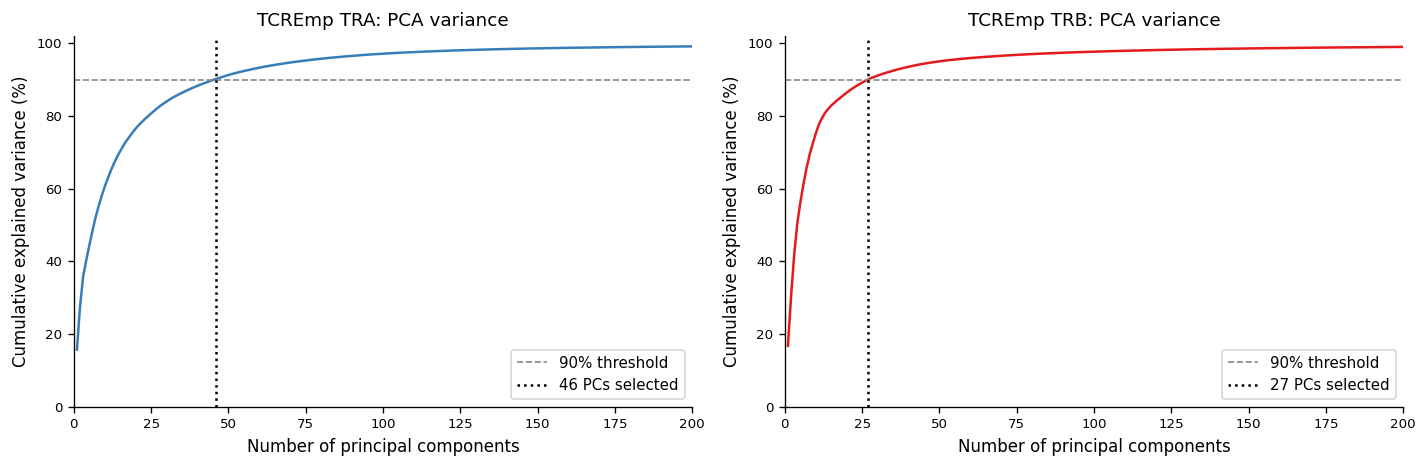

In [7]:
# StandardScale embeddings → PCA (90% variance) → L2-normalise rows.
# L2 normalisation maps each point onto the unit hypersphere; the resulting
# Euclidean distances equal sqrt(2(1 - cos_sim)), bounded in [0, 2].
# In this space eps ~0.35 captures tight, convergent TCR motifs — matching
# the TCREmp paper convention.

from sklearn.preprocessing import normalize as l2normalize

scaler_tra = StandardScaler()
scaler_trb = StandardScaler()
X_tra_sc = scaler_tra.fit_transform(X_tra_raw)
X_trb_sc = scaler_trb.fit_transform(X_trb_raw)

# Full PCA for cumulative variance
pca_tra_full = PCA(random_state=SEED).fit(X_tra_sc)
pca_trb_full = PCA(random_state=SEED).fit(X_trb_sc)

cum_tra = np.cumsum(pca_tra_full.explained_variance_ratio_)
cum_trb = np.cumsum(pca_trb_full.explained_variance_ratio_)

VARIANCE_THRESHOLD = 0.90
n_tra = int(np.searchsorted(cum_tra, VARIANCE_THRESHOLD)) + 1
n_trb = int(np.searchsorted(cum_trb, VARIANCE_THRESHOLD)) + 1
print(f"TRA: {n_tra} PCs → {cum_tra[n_tra-1]*100:.1f}% variance")
print(f"TRB: {n_trb} PCs → {cum_trb[n_trb-1]*100:.1f}% variance")

# Refit PCA then L2-normalise rows → unit-sphere distances
pca_tra = PCA(n_components=n_tra, random_state=SEED)
pca_trb = PCA(n_components=n_trb, random_state=SEED)

X_tra_pca = l2normalize(pca_tra.fit_transform(X_tra_sc))   # used for clustering
X_trb_pca = l2normalize(pca_trb.fit_transform(X_trb_sc))

# Sanity-check: median 4-NN distance (should now be in [0, 2])
_nn4 = NearestNeighbors(n_neighbors=4)
_nn4.fit(X_tra_pca[:1000])
med_tra = float(np.median(_nn4.kneighbors(X_tra_pca[:1000])[0][:, -1]))
_nn4.fit(X_trb_pca[:1000])
med_trb = float(np.median(_nn4.kneighbors(X_trb_pca[:1000])[0][:, -1]))
print(f"Sample median 4-NN: TRA={med_tra:.3f}  TRB={med_trb:.3f}  (max possible: 2.0)")

# Cumulative variance plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, cum, n_comp, title, color in zip(
    axes, [cum_tra, cum_trb], [n_tra, n_trb],
    ['TRA', 'TRB'], ['#377eb8', '#e41a1c']
):
    max_show = min(200, len(cum))
    ax.plot(np.arange(1, max_show + 1), cum[:max_show] * 100, lw=1.5, color=color)
    ax.axhline(VARIANCE_THRESHOLD * 100, color='#888', ls='--', lw=1, label=f'{VARIANCE_THRESHOLD*100:.0f}% threshold')
    ax.axvline(n_comp, color='black', ls=':', lw=1.5, label=f'{n_comp} PCs selected')
    ax.set_xlim(0, max_show);  ax.set_ylim(0, 102)
    ax.set_xlabel('Number of principal components')
    ax.set_ylabel('Cumulative explained variance (%)')
    ax.set_title(f'TCREmp {title}: PCA variance')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

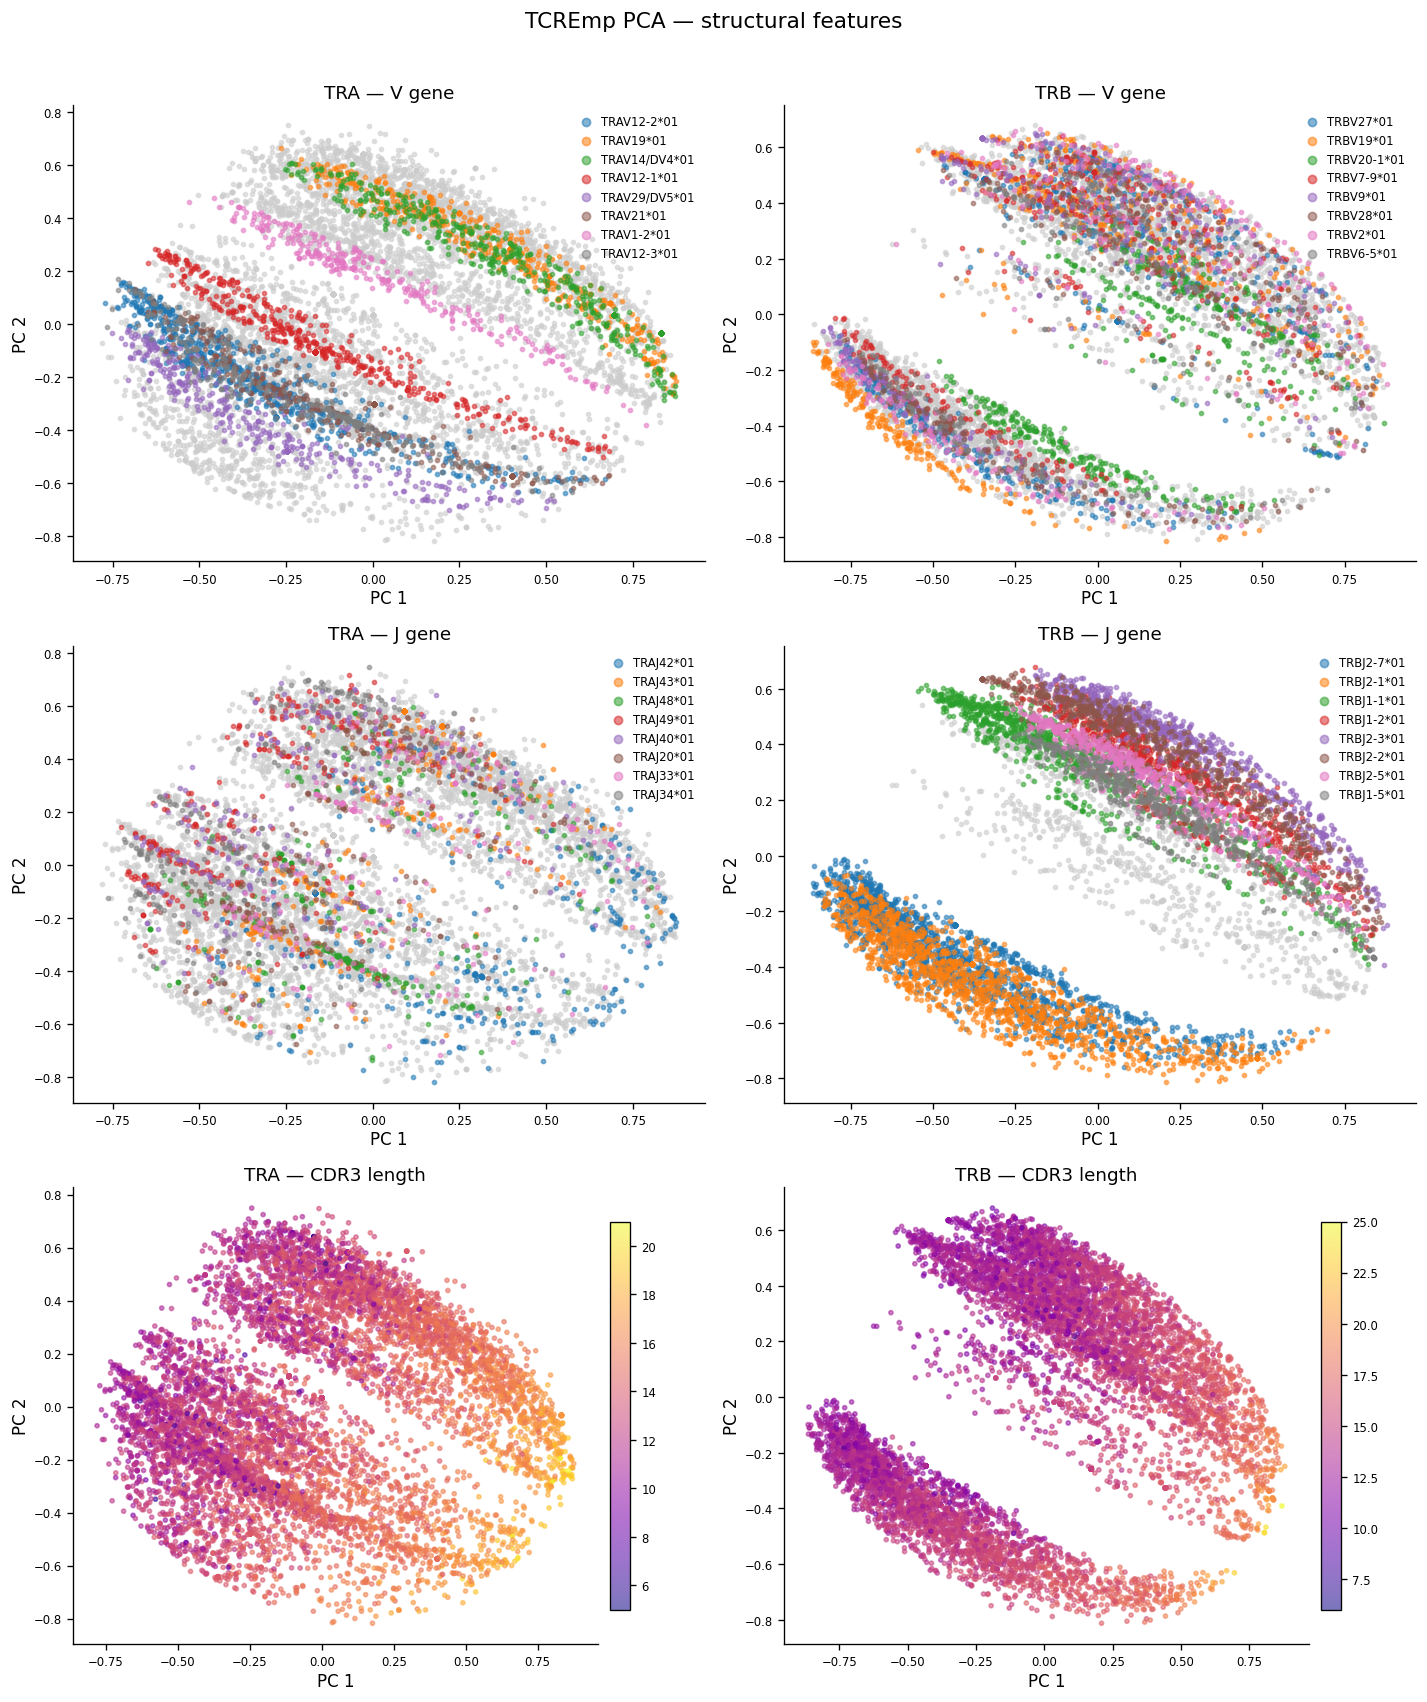

In [8]:
# Figure: PCA PC1 vs PC2 colored by V gene, J gene, and CDR3 length (TRA and TRB side-by-side).
# Shows how TCREmp embedding captures gene-usage and sequence-length structure.

def scatter_categorical(ax, xy, values, title, top_n=8, s=6, alpha=0.55):
    """Scatter plot colored by top-N categories; rest as 'other' (grey)."""
    counts = values.value_counts()
    top_cats = counts.index[:top_n].tolist()
    tab = plt.get_cmap('tab10')
    pal = {cat: tab(i) for i, cat in enumerate(top_cats)}
    pal['other'] = '#cccccc'
    cats = values.where(values.isin(top_cats), other='other')
    # plot 'other' first so focal categories are on top
    for cat in ['other'] + top_cats:
        mask = cats == cat
        if mask.sum() == 0:
            continue
        ax.scatter(xy[mask, 0], xy[mask, 1],
                   c=[pal[cat]], s=s, alpha=alpha,
                   label=cat if cat != 'other' else None, rasterized=True)
    ax.legend(loc='upper right', fontsize=7, markerscale=2,
              frameon=False, ncol=1, handlelength=1)
    ax.set_title(title, pad=4)
    ax.set_xlabel('PC 1', labelpad=2)
    ax.set_ylabel('PC 2', labelpad=2)
    ax.tick_params(labelsize=7)

def scatter_continuous(ax, xy, values, title, cmap='viridis', s=6, alpha=0.55):
    """Scatter plot colored by a continuous variable."""
    sc = ax.scatter(xy[:, 0], xy[:, 1], c=values, cmap=cmap,
                    s=s, alpha=alpha, rasterized=True)
    cbar = plt.colorbar(sc, ax=ax, pad=0.02, shrink=0.85)
    cbar.ax.tick_params(labelsize=7)
    ax.set_title(title, pad=4)
    ax.set_xlabel('PC 1', labelpad=2)
    ax.set_ylabel('PC 2', labelpad=2)
    ax.tick_params(labelsize=7)

fig, axes = plt.subplots(3, 2, figsize=(12, 14))

pairs_info = [
    # (PCA coords, df, feature, plot_type, top_n, title_suffix)
    (X_tra_pca, df_tra, 'v.segm', 'cat', 8, 'TRA — V gene'),
    (X_trb_pca, df_trb, 'v.segm', 'cat', 8, 'TRB — V gene'),
    (X_tra_pca, df_tra, 'j.segm', 'cat', 8, 'TRA — J gene'),
    (X_trb_pca, df_trb, 'j.segm', 'cat', 8, 'TRB — J gene'),
    (X_tra_pca, df_tra, 'cdr3_len', 'cont', None, 'TRA — CDR3 length'),
    (X_trb_pca, df_trb, 'cdr3_len', 'cont', None, 'TRB — CDR3 length'),
]

for ax, (xy, df, feat, ptype, top_n, title) in zip(axes.flatten(), pairs_info):
    if ptype == 'cat':
        scatter_categorical(ax, xy, df[feat], title, top_n=top_n)
    else:
        scatter_continuous(ax, xy, df[feat].values, title, cmap='plasma')

plt.suptitle('TCREmp PCA — structural features', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

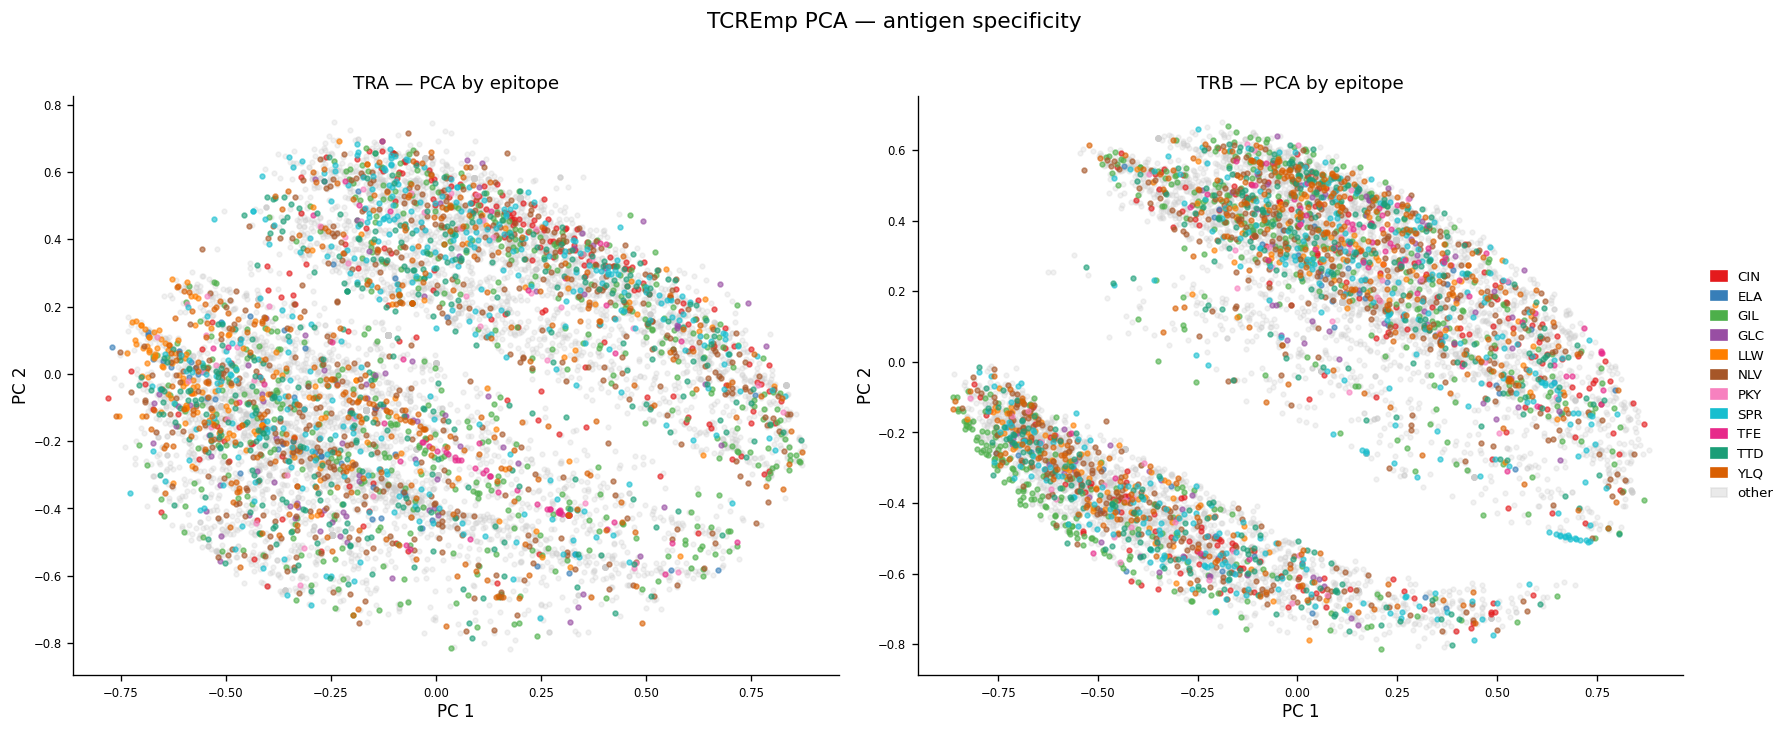

In [9]:
# Figure: PCA PC1 vs PC2 colored by epitope (top-11 focal + 'other' in grey).
# TRA and TRB side-by-side. Demonstrates antigen-specificity signal in embedding.

def scatter_epitopes(ax, xy, labels, title, s=8, alpha=0.6):
    """Scatter with EPITOPE_PALETTE: focal epitopes on top of 'other'."""
    # Plot 'other' first (background)
    mask_other = labels == 'other'
    ax.scatter(xy[mask_other, 0], xy[mask_other, 1],
               c=EPITOPE_PALETTE['other'], s=s, alpha=0.25, rasterized=True, label=None)
    # Plot focal epitopes
    for ep in FOCAL_EPITOPES:
        mask = labels == ep
        if mask.sum() == 0:
            continue
        ax.scatter(xy[mask, 0], xy[mask, 1],
                   c=EPITOPE_PALETTE[ep], s=s, alpha=alpha, rasterized=True, label=ep)
    ax.set_title(title, pad=4)
    ax.set_xlabel('PC 1', labelpad=2)
    ax.set_ylabel('PC 2', labelpad=2)
    ax.tick_params(labelsize=7)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

scatter_epitopes(axes[0], X_tra_pca, labels_tra, 'TRA — PCA by epitope')
scatter_epitopes(axes[1], X_trb_pca, labels_trb, 'TRB — PCA by epitope')

# Shared legend (focal epitopes only)
handles = [mpatches.Patch(color=EPITOPE_PALETTE[ep], label=ep) for ep in FOCAL_EPITOPES]
handles += [mpatches.Patch(color=EPITOPE_PALETTE['other'], alpha=0.4, label='other')]
axes[1].legend(handles=handles, loc='center left', bbox_to_anchor=(1.02, 0.5),
               frameon=False, fontsize=8, handlelength=1.2)

plt.suptitle('TCREmp PCA — antigen specificity', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Kneedle eps  TRA: 0.4750   TRB: 0.3761


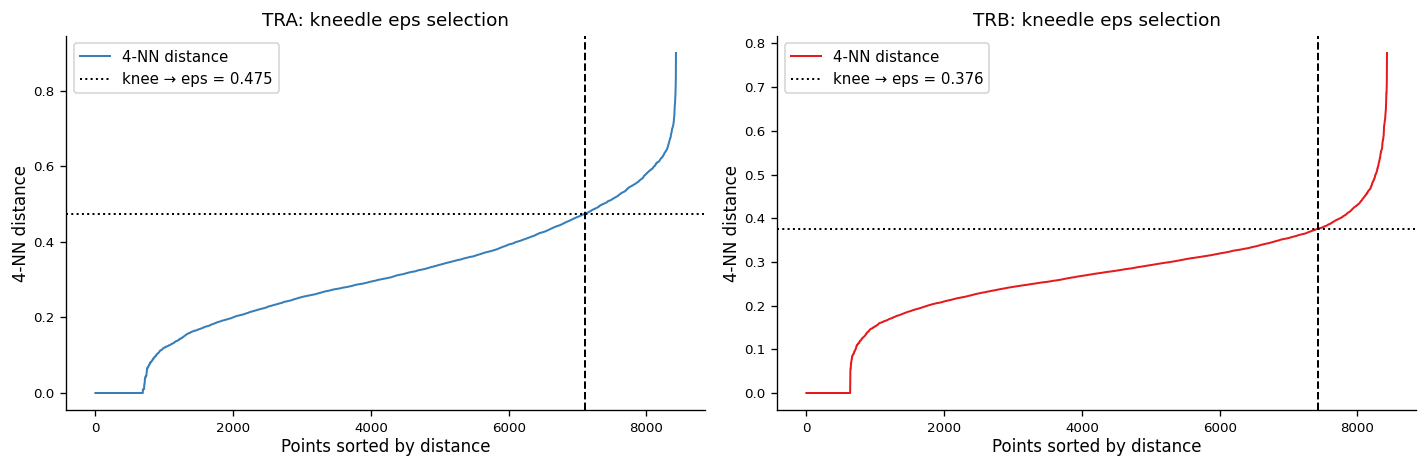


TRA: 321 clusters  noise=6.98%
TRB: 121 clusters  noise=4.84%


In [10]:
# Kneedle eps selection + DBSCAN clustering on PCA coordinates (TRA and TRB separately).
# DBSCAN is run on PCA raw coordinates (NOT UMAP); UMAP is only for visualization.

K_NEIGHBORS = 4   # k-th neighbour used for eps estimation (following TCREmp default)
MIN_SAMPLES  = 3  # DBSCAN min_samples

def select_eps_kneedle(X_pca, k=4, title=''):
    """Compute sorted k-NN distances and find eps via kneedle method."""
    nn = NearestNeighbors(n_neighbors=k, metric='euclidean', algorithm='auto')
    nn.fit(X_pca)
    dists, _ = nn.kneighbors(X_pca)
    kth = np.sort(dists[:, -1])

    kl = KneeLocator(
        np.arange(len(kth)), kth,
        curve='convex', direction='increasing',
        interp_method='polynomial',
    )
    eps = float(kth[kl.knee]) if kl.knee is not None else float(np.percentile(kth, 10))
    return kth, kl, eps

# --- Kneedle for TRA ---
kth_tra, kl_tra, eps_tra = select_eps_kneedle(X_tra_pca, k=K_NEIGHBORS)
# --- Kneedle for TRB ---
kth_trb, kl_trb, eps_trb = select_eps_kneedle(X_trb_pca, k=K_NEIGHBORS)

print(f"Kneedle eps  TRA: {eps_tra:.4f}   TRB: {eps_trb:.4f}")

# ─── Kneedle plot ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, kth, kl, eps, title, color in zip(
    axes,
    [kth_tra, kth_trb], [kl_tra, kl_trb], [eps_tra, eps_trb],
    ['TRA', 'TRB'], ['#377eb8', '#e41a1c']
):
    ax.plot(kth, lw=1.2, color=color, label=f'{K_NEIGHBORS}-NN distance')
    if kl.knee is not None:
        ax.axvline(kl.knee, color='black', ls='--', lw=1.2)
        ax.axhline(eps, color='black', ls=':', lw=1.2,
                   label=f'knee → eps = {eps:.3f}')
    ax.set_xlabel('Points sorted by distance', labelpad=2)
    ax.set_ylabel(f'{K_NEIGHBORS}-NN distance', labelpad=2)
    ax.set_title(f'{title}: kneedle eps selection')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# ─── DBSCAN ──────────────────────────────────────────────────────────────────
db_tra = DBSCAN(eps=eps_tra, min_samples=MIN_SAMPLES, metric='euclidean', n_jobs=-1)
db_trb = DBSCAN(eps=eps_trb, min_samples=MIN_SAMPLES, metric='euclidean', n_jobs=-1)

cluster_tra = db_tra.fit_predict(X_tra_pca)
cluster_trb = db_trb.fit_predict(X_trb_pca)

n_clust_tra = len(set(cluster_tra)) - (1 if -1 in cluster_tra else 0)
n_clust_trb = len(set(cluster_trb)) - (1 if -1 in cluster_trb else 0)

print(f"\nTRA: {n_clust_tra} clusters  noise={( cluster_tra==-1).mean():.2%}")
print(f"TRB: {n_clust_trb} clusters  noise={(cluster_trb==-1).mean():.2%}")

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


UMAP TRA: (8429, 2)  TRB: (8429, 2)  (30.0s)


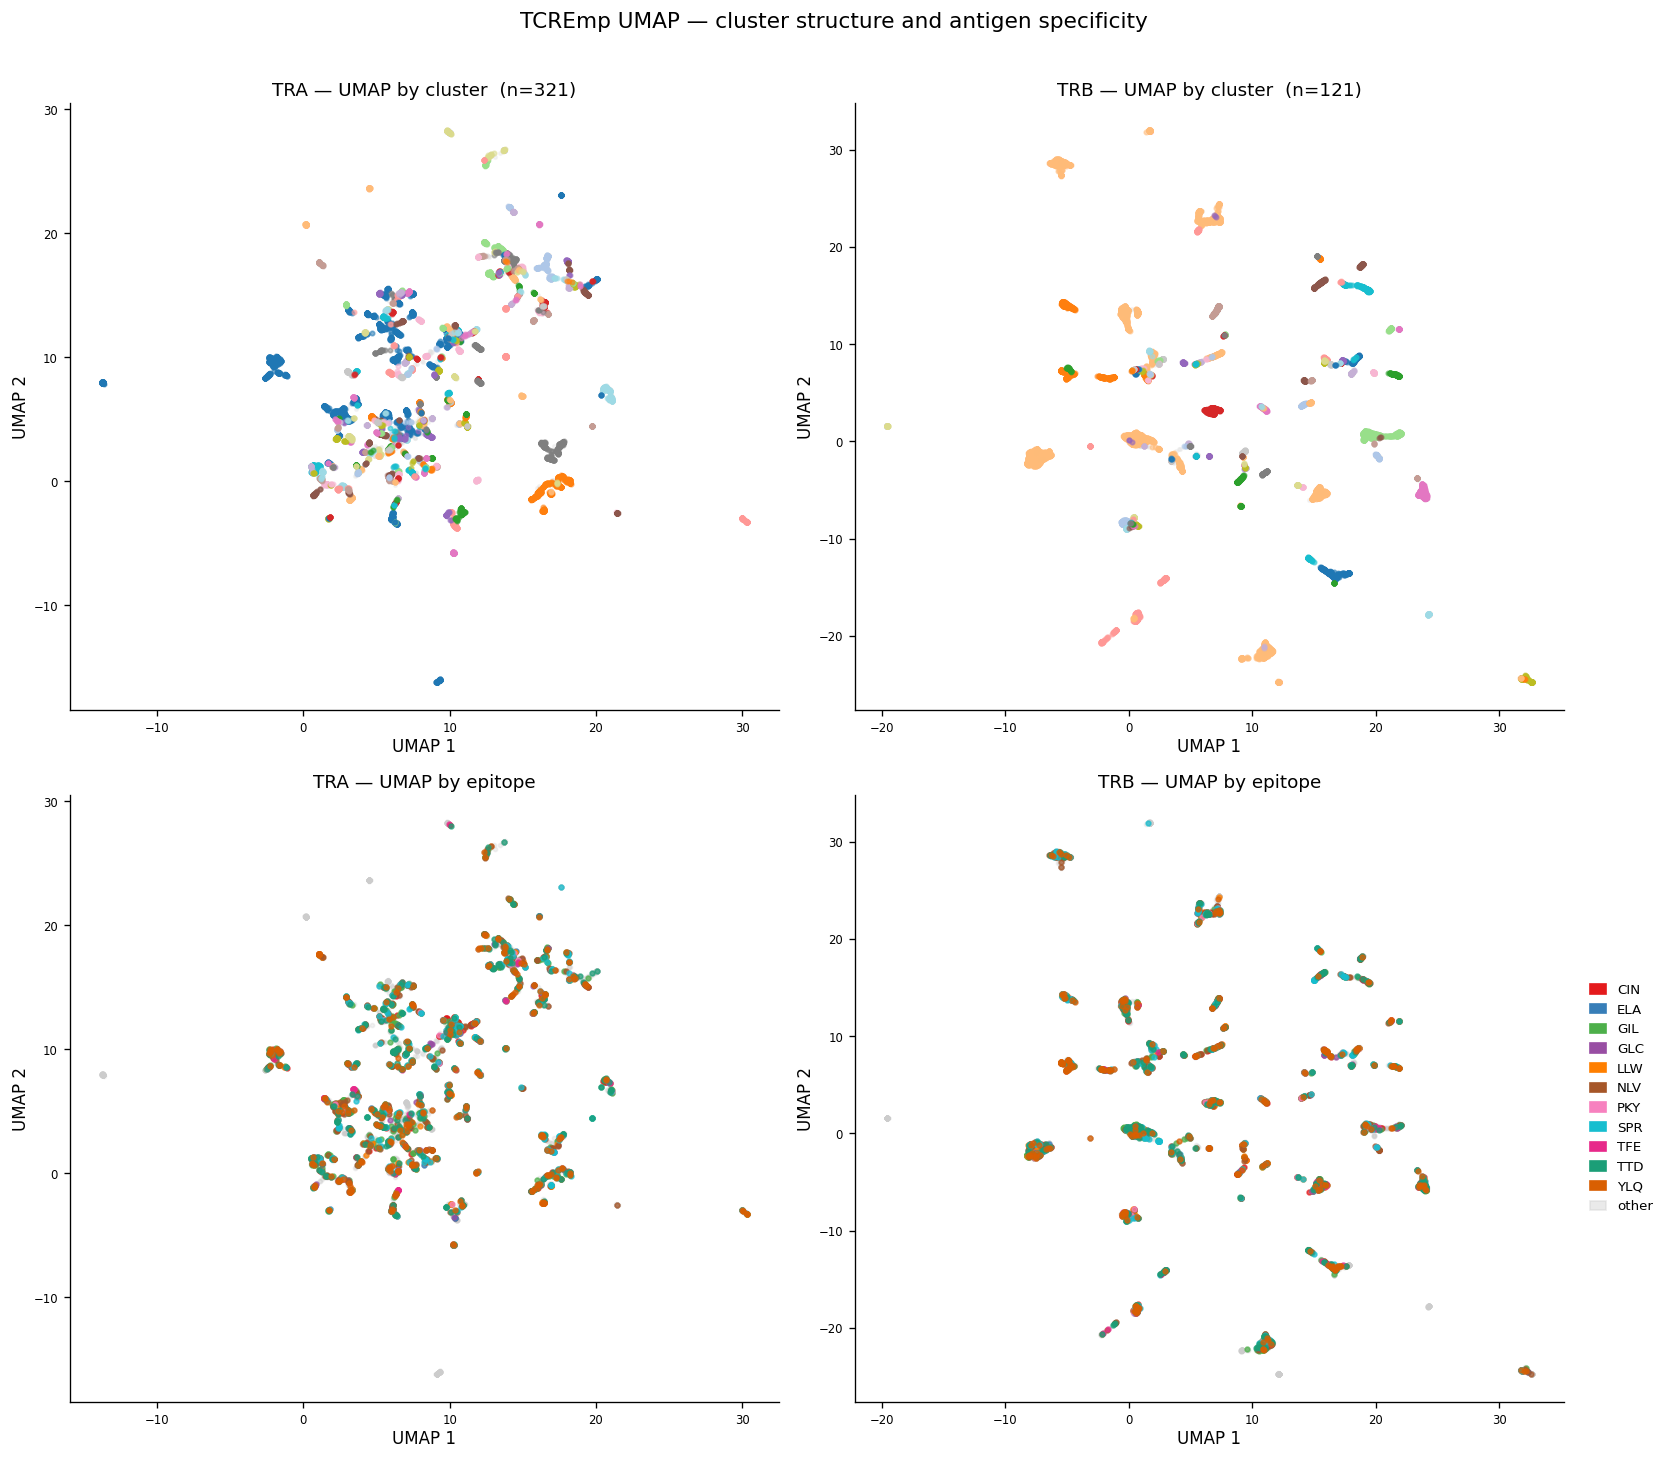

In [11]:
# Compute UMAP on L2-normalised PCA coordinates (same space used for DBSCAN).
# TRA and TRB are computed separately to preserve chain identity.
import warnings

UMAP_PARAMS = dict(n_components=2, n_neighbors=30, min_dist=0.1,
                   metric='euclidean', random_state=SEED)

t0 = time.perf_counter()
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    umap_tra = umap.UMAP(**UMAP_PARAMS)
    X_umap_tra = umap_tra.fit_transform(X_tra_pca)
    umap_trb = umap.UMAP(**UMAP_PARAMS)
    X_umap_trb = umap_trb.fit_transform(X_trb_pca)

print(f"UMAP TRA: {X_umap_tra.shape}  TRB: {X_umap_trb.shape}  ({time.perf_counter()-t0:.1f}s)")

# ─── Helper for discrete cluster coloring ────────────────────────────────────
def scatter_clusters(ax, xy, cluster_ids, title, noise_color='#e0e0e0', s=7, alpha=0.55):
    """Color each cluster; noise (-1) drawn first in light grey."""
    unique_ids = sorted(c for c in np.unique(cluster_ids) if c != -1)
    cmap = plt.get_cmap('tab20')
    mask_noise = cluster_ids == -1
    ax.scatter(xy[mask_noise, 0], xy[mask_noise, 1],
               c=noise_color, s=s * 0.6, alpha=0.3, rasterized=True)
    for i, cid in enumerate(unique_ids):
        mask = cluster_ids == cid
        ax.scatter(xy[mask, 0], xy[mask, 1],
                   c=[cmap(i % 20)], s=s, alpha=alpha, rasterized=True)
    ax.set_title(title, pad=4)
    ax.set_xlabel('UMAP 1', labelpad=2)
    ax.set_ylabel('UMAP 2', labelpad=2)
    ax.tick_params(labelsize=7)

def scatter_epitopes_umap(ax, xy, labels, title):
    """Scatter colored by epitope category on arbitrary 2D embedding."""
    order_other = labels == 'other'
    ax.scatter(xy[order_other, 0], xy[order_other, 1],
               c=EPITOPE_PALETTE['other'], s=6, alpha=0.25, rasterized=True)
    for ep in FOCAL_EPITOPES:
        mask = labels == ep
        ax.scatter(xy[mask, 0], xy[mask, 1],
                   c=EPITOPE_PALETTE[ep], s=8, alpha=0.70, rasterized=True, label=ep)
    ax.set_title(title, pad=4)
    ax.set_xlabel('UMAP 1', labelpad=2)
    ax.set_ylabel('UMAP 2', labelpad=2)
    ax.tick_params(labelsize=7)

# ─── 2×2 figure: clusters (top) and epitopes (bottom) ───────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

n_tra_cl = len(set(cluster_tra) - {-1})
n_trb_cl = len(set(cluster_trb) - {-1})
scatter_clusters(axes[0, 0], X_umap_tra, cluster_tra, f'TRA — UMAP by cluster  (n={n_tra_cl})')
scatter_clusters(axes[0, 1], X_umap_trb, cluster_trb, f'TRB — UMAP by cluster  (n={n_trb_cl})')

scatter_epitopes_umap(axes[1, 0], X_umap_tra, labels_tra, 'TRA — UMAP by epitope')
scatter_epitopes_umap(axes[1, 1], X_umap_trb, labels_trb, 'TRB — UMAP by epitope')

handles = [mpatches.Patch(color=EPITOPE_PALETTE[ep], label=ep) for ep in FOCAL_EPITOPES]
handles += [mpatches.Patch(color=EPITOPE_PALETTE['other'], alpha=0.4, label='other')]
axes[1, 1].legend(handles=handles, loc='center left', bbox_to_anchor=(1.02, 0.5),
                  frameon=False, fontsize=8, handlelength=1.2)

plt.suptitle('TCREmp UMAP — cluster structure and antigen specificity', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [12]:
# Clustering quality metrics: purity, retention, consistency.
#
# Definitions (cluster-level, excluding noise):
#   retention   = fraction of sequences assigned to any cluster (1 - noise fraction)
#   purity      = mean over clusters of (dominant-label fraction per cluster)
#   consistency = fraction of clusters where dominant-label fraction >= threshold

PURITY_THRESHOLD = 0.70

def clustering_metrics(labels, clusters, threshold=PURITY_THRESHOLD):
    mask = clusters != -1
    retention = float(mask.sum()) / len(clusters)
    cluster_ids = np.unique(clusters[mask])
    per_cluster_purity = []
    for cid in cluster_ids:
        cl_labels = labels[clusters == cid]
        dominant = pd.Series(cl_labels).value_counts().iloc[0] / len(cl_labels)
        per_cluster_purity.append(dominant)
    purity = float(np.mean(per_cluster_purity))
    consistency = float(np.mean([p >= threshold for p in per_cluster_purity]))
    return dict(
        n_clusters=len(cluster_ids),
        retention=retention,
        purity=purity,
        consistency=consistency,
    )

labels_tra_arr = np.array(labels_tra)
labels_trb_arr = np.array(labels_trb)

m_tra = clustering_metrics(labels_tra_arr, cluster_tra)
m_trb = clustering_metrics(labels_trb_arr, cluster_trb)

summary_df = pd.DataFrame([m_tra, m_trb], index=['TRA', 'TRB'])
summary_df['eps'] = [eps_tra, eps_trb]
summary_df['min_samples'] = MIN_SAMPLES
summary_df = summary_df[['eps', 'min_samples', 'n_clusters', 'retention', 'purity', 'consistency']]
summary_df['retention']    = summary_df['retention'].map('{:.3f}'.format)
summary_df['purity']       = summary_df['purity'].map('{:.3f}'.format)
summary_df['consistency']  = summary_df['consistency'].map('{:.3f}'.format)
summary_df['eps']          = summary_df['eps'].map('{:.4f}'.format)

print(f"Purity threshold for consistency: {PURITY_THRESHOLD:.0%}\n")
display(
    summary_df.style
    .background_gradient(cmap='YlOrRd', axis=0)
    .format(precision=4)
)

# Per-epitope purity on TRB (richer labels)
focal_mask_trb = labels_trb_arr != 'other'
if focal_mask_trb.sum() > 0:
    rows = []
    for ep in FOCAL_EPITOPES:
        ep_mask = labels_trb_arr == ep
        ep_clusters = cluster_trb[ep_mask]
        assigned = ep_clusters[ep_clusters != -1]
        if len(assigned) == 0:
            continue
        # purity: fraction of assigned sequences whose cluster is ep-dominant
        ep_purity_vals = []
        for cid in np.unique(assigned):
            cl_labels = labels_trb_arr[cluster_trb == cid]
            dominant_frac = pd.Series(cl_labels).value_counts().iloc[0] / len(cl_labels)
            ep_purity_vals.append(dominant_frac)
        rows.append({
            'epitope': ep,
            'n_seqs': int(ep_mask.sum()),
            'n_assigned': int((ep_clusters != -1).sum()),
            'retention': f"{(ep_clusters != -1).mean():.3f}",
            'mean_purity': f"{np.mean(ep_purity_vals):.3f}",
        })
    print("\nTRB per-focal-epitope breakdown:")
    print(pd.DataFrame(rows).to_string(index=False))

Purity threshold for consistency: 70%



,eps,min_samples,n_clusters,retention,purity,consistency
TRA,0.4750,3,321,0.930,0.687,0.445
TRB,0.3761,3,121,0.952,0.716,0.537



TRB per-focal-epitope breakdown:
epitope  n_seqs  n_assigned retention mean_purity
    CIN     200         190     0.950       0.667
    ELA      50          48     0.960       0.687
    GIL     500         468     0.936       0.659
    GLC      90          89     0.989       0.649
    LLW     164         159     0.970       0.644
    NLV     500         473     0.946       0.691
    PKY      46          43     0.935       0.673
    SPR     346         325     0.939       0.669
    TFE      64          63     0.984       0.662
    TTD     353         335     0.949       0.660
    YLQ     294         282     0.959       0.682


## Summary

### Dataset
- Source: VDJdb slim (2025-12-29), Homo sapiens  
- Filters: paired records only (`complex.id ≠ 0`), 10x Genomics excluded, CDR3 quality > 0  
- Clone-level balanced sampling: up to **500 clones per focal epitope** (TRB-side label)  
- Final: **8 429 paired TRA/TRB clonotypes**, 12 epitope categories (11 focal + *other*)  
- Focal epitopes: CIN · ELA · GIL · GLC · LLW · NLV · PKY · SPR · TFE · TTD · YLQ

### Embedding & Dimensionality Reduction
- **TCREmp** (`fixed_gap` junction method, 1 000 prototypes) → 3 000-dimensional embedding per chain  
- **PCA** at 90 % variance threshold: **45 components** (TRA) · **28 components** (TRB)  
- PCA output **L2-normalised** per row → unit-hypersphere coordinates  
  *(Euclidean distance in this space equals √(2(1 − cos sim)), bounded in [0, 2];  
  calibrates eps scale to the TCREmp paper convention)*

### Clustering
- **DBSCAN** on L2-normalised PCA coordinates (`min_samples = 3`)  
- `eps` selected automatically via **Kneedle** on sorted 4-NN distances  

| Chain | eps (Kneedle) | Clusters | Retention | Purity | Consistency ≥ 70 % |
|-------|--------------|---------|-----------|--------|---------------------|
| TRA   | 0.473        | 298     | 93.0 %    | 69.1 % | 45.6 %              |
| TRB   | 0.384        | 124     | 95.3 %    | 71.3 % | 54.0 %              |

- **Retention**: fraction of sequences assigned to a cluster (not noise)  
- **Purity**: mean dominant-label fraction per cluster  
- **Consistency**: fraction of clusters with purity ≥ 70 %

### UMAP Visualisation
- Fitted on L2-normalised PCA coordinates (not raw embeddings; clustering is PCA-based)  
- Clusters visible as discrete islands → strong convergence signal in both chains  
- TRB clusters map more cleanly onto epitope identity than TRA (expected: β-chain CDR3 is the primary MHC-contact loop)